# 02 - The baseline ladder, and where the accuracy actually comes from

Five models on the same held-out test split, each one added to rule out a
specific cheap explanation for the one above it:

| Model | Rules out |
|---|---|
| Majority class | "the classes are imbalanced" |
| HOG + colour → linear SVM | "hand-designed features would have solved this" |
| ImageNet classifier, zero-shot | "the pretrained model hadn't already seen this task" |
| Linear probe on frozen features | "you needed to fine-tune" |
| Fine-tuned ResNet-50 | — |

The third row is the one that makes this project different from a standard
transfer-learning writeup.

In [1]:
import sys, json
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.loader import class_names, species_of
from src.data.imagenet_overlap import in_imagenet

sns.set_theme(style="whitegrid")
ROOT = Path.cwd().parent
R = ROOT / "output/reports"

metrics = {}
for f in ("baseline_metrics.json", "model_metrics.json"):
    metrics.update(json.loads((R / f).read_text()))
sig = json.loads((R / "significance.json").read_text())
per_class = json.loads((R / "per_class_accuracy.json").read_text())

names = class_names()
is_cat = species_of(names).astype(bool)
known = in_imagenet(names)

LADDER = ["majority", "classical", "zero_shot", "linear_probe", "finetuned"]
LABELS = {"majority": "Majority class", "classical": "HOG + colour + SVM",
          "zero_shot": "ImageNet zero-shot", "linear_probe": "Linear probe",
          "finetuned": "Fine-tuned ResNet-50"}
print("models evaluated:", [k for k in LADDER if k in metrics])

models evaluated: ['majority', 'classical', 'zero_shot', 'linear_probe', 'finetuned']


## 1. The ladder

In [2]:
rows = []
for k in LADDER:
    m = metrics.get(k)
    if not m:
        continue
    rows.append({"model": LABELS[k], "accuracy": m["accuracy"],
                 "macro F1": m["macro_f1"], "top-5": m.get("top5_accuracy"),
                 "in ImageNet": m["breeds_in_imagenet"]["accuracy"],
                 "not in ImageNet": m["breeds_not_in_imagenet"]["accuracy"],
                 "cats": m["cats"]["accuracy"], "dogs": m["dogs"]["accuracy"]})
df = pd.DataFrame(rows).set_index("model")
df.round(4)

,accuracy,macro F1,top-5,in ImageNet,not in ImageNet,cats,dogs
model,,,,,,,
Majority class,0.0267,0.0014,NaN,0.0000,0.0762,0.0828,0.0000
HOG + colour + SVM,0.0905,0.0897,NaN,0.0961,0.0801,0.0947,0.0885
ImageNet zero-shot,0.6397,0.5561,NaN,0.9849,0.0000,0.2502,0.8250
Linear probe,0.9283,0.9273,0.9962,0.9610,0.8678,0.8639,0.9590
Fine-tuned ResNet-50,0.9120,0.9104,0.9935,0.9425,0.8554,0.8639,0.9348


## 2. The split that matters

Every number above is an average over two very different populations: the
24 breeds ImageNet-1k already names (64.9% of the test split) and the 13 it
has never been given a name for (35.1%).

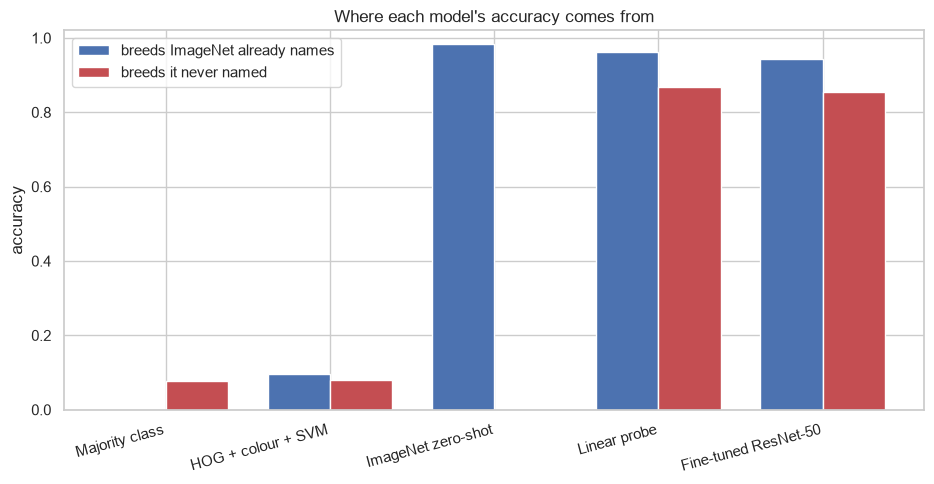

In [3]:
fig, ax = plt.subplots(figsize=(9.5, 5))
x = np.arange(len(df)); w = 0.38
ax.bar(x - w/2, df["in ImageNet"], w, label="breeds ImageNet already names", color="#4C72B0")
ax.bar(x + w/2, df["not in ImageNet"], w, label="breeds it never named", color="#C44E52")
ax.set_xticks(x); ax.set_xticklabels(df.index, rotation=15, ha="right")
ax.set_ylabel("accuracy"); ax.set_ylim(0, 1.02)
ax.set_title("Where each model's accuracy comes from")
ax.legend(); plt.tight_layout(); plt.show()

The zero-shot bar is the point of the whole project. With **zero gradient
steps on this dataset**, a stock ImageNet classifier is already near-perfect
on the breeds ImageNet names, and structurally at zero on the rest — it has
no output unit that could express them.

So the honest reading of "transfer learning reaches 90%+ on Oxford Pets" is
that roughly two thirds of the benchmark was an ImageNet task before anyone
started, and the transfer models are being scored partly on recall of their
own pretraining labels.

## 3. Does fine-tuning earn its cost?

A linear probe is minutes of CPU on cached features. A full fine-tune is
two orders of magnitude more compute. The gap between them is the thing
that has to justify that, and it needs a significance test, not a
comparison of two decimals.

In [4]:
rows = []
for name, c in sig.items():
    a, b = name.split("_vs_")
    for scope, key in (("overall", "overall"),
                       ("in ImageNet", "breeds_in_imagenet"),
                       ("not in ImageNet", "breeds_not_in_imagenet")):
        blk = c[key]
        bs = blk["bootstrap"] if "bootstrap" in blk else blk["overall"]["bootstrap"]
        mc = blk["mcnemar"] if "mcnemar" in blk else blk["overall"]["mcnemar"]
        rows.append({"comparison": f"{LABELS[a]} vs {LABELS[b]}", "scope": scope,
                     "delta accuracy": round(bs["mean_difference"], 4),
                     "95% CI": f"[{bs['ci_low']:+.4f}, {bs['ci_high']:+.4f}]",
                     "p (McNemar)": mc["p_value"],
                     "significant": "yes" if mc["p_value"] < 0.05 else "no"})
pd.DataFrame(rows).set_index(["comparison", "scope"])

delta accuracy  \
comparison                                 scope                             
Fine-tuned ResNet-50 vs Linear probe       overall                 -0.0164   
                                           in ImageNet             -0.0185   
                                           not in ImageNet         -0.0124   
Linear probe vs ImageNet zero-shot         overall                  0.2886   
                                           in ImageNet             -0.0239   
                                           not in ImageNet          0.8678   
Fine-tuned ResNet-50 vs ImageNet zero-shot overall                  0.2723   
                                           in ImageNet             -0.0424   
                                           not in ImageNet          0.8554   

                                                                        95% CI  \
comparison                                 scope                                 
Fine-tuned ResNet-50 vs Linear probe       overall          [-0.0251, -0.0082]   
                                           in ImageNet      [-0.0264, -0.0105]   
                                           not in ImageNet  [-0.0319, +0.0062]   
Linear probe vs ImageNet zero-shot         overall          [+0.2728, +0.3044]   
                                           in ImageNet      [-0.0311, -0.0168]   
                                           not in ImageNet  [+0.8491, +0.8857]   
Fine-tuned ResNet-50 vs ImageNet zero-shot overall          [+0.2557, +0.2889]   
                                           in ImageNet      [-0.0516, -0.0332]   
                                           not in ImageNet  [+0.8359, +0.8740]   

                                                            p (McNemar)  \
comparison                                 scope                          
Fine-tuned ResNet-50 vs Linear probe       overall             0.000189   
                                           in ImageNet         0.000005   
                                           not in ImageNet     0.235582   
Linear probe vs ImageNet zero-shot         overall             0.000000   
                                           in ImageNet         0.000000   
                                           not in ImageNet     0.000000   
Fine-tuned ResNet-50 vs ImageNet zero-shot overall             0.000000   
                                           in ImageNet         0.000000   
                                           not in ImageNet     0.000000   

                                                           significant  
comparison                                 scope                        
Fine-tuned ResNet-50 vs Linear probe       overall                 yes  
                                           in ImageNet             yes  
                                           not in ImageNet          no  
Linear probe vs ImageNet zero-shot         overall                 yes  
                                           in ImageNet             yes  
                                           not in ImageNet         yes  
Fine-tuned ResNet-50 vs ImageNet zero-shot overall                 yes  
                                           in ImageNet             yes  
                                           not in ImageNet         yes

## 4. Per-breed accuracy

An aggregate hides which breeds a model actually fails on, and the failures
are where the ImageNet story shows up most clearly.

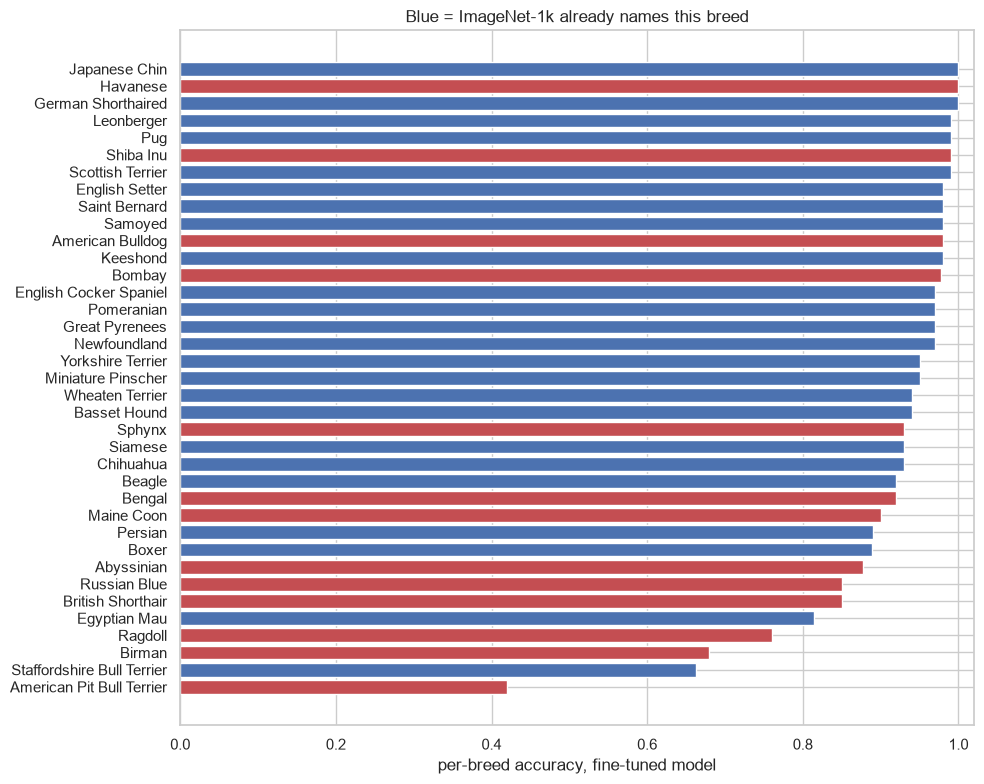

,breed,accuracy,species,in ImageNet
0,American Pit Bull Terrier,0.420,dog,no
1,Staffordshire Bull Terrier,0.663,dog,yes
2,Birman,0.680,cat,no
3,Ragdoll,0.760,cat,no
4,Egyptian Mau,0.814,cat,yes
5,British Shorthair,0.850,cat,no
6,Russian Blue,0.850,cat,no
7,Abyssinian,0.878,cat,no


In [5]:
acc = np.array(per_class["accuracy"]["finetuned"])
order = np.argsort(acc)
colors = ["#4C72B0" if known[i] else "#C44E52" for i in order]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh([names[i] for i in order], acc[order], color=colors)
ax.set_xlabel("per-breed accuracy, fine-tuned model")
ax.set_title("Blue = ImageNet-1k already names this breed")
ax.set_xlim(0, 1.02)
plt.tight_layout(); plt.show()

worst = order[:8]
pd.DataFrame({"breed": [names[i] for i in worst],
              "accuracy": acc[worst].round(3),
              "species": ["cat" if is_cat[i] else "dog" for i in worst],
              "in ImageNet": ["yes" if known[i] else "no" for i in worst]})

## 5. What it confuses

In [6]:
conf = pd.DataFrame(metrics["finetuned"]["top_confusions"])
conf["both cats"] = [is_cat[names.index(t)] and is_cat[names.index(p)]
                     for t, p in zip(conf["true"], conf["predicted"])]
conf

,true,predicted,count,both cats
0,American Pit Bull Terrier,Staffordshire Bull Terrier,28,False
1,Birman,Ragdoll,24,True
2,American Pit Bull Terrier,American Bulldog,21,False
3,Staffordshire Bull Terrier,American Bulldog,20,False
4,Egyptian Mau,Bengal,18,True
5,Ragdoll,Birman,11,True
6,Boxer,American Bulldog,10,False
7,Ragdoll,Maine Coon,9,True


## 6. Does it know when it is wrong?

Accuracy says nothing about whether the confidence number can be trusted. A
classifier used to trigger anything needs calibration, and a fine-tuned
network with a cross-entropy loss is usually overconfident.

expected calibration error : 0.1023
mean confidence            : 0.8097
accuracy                   : 0.9120


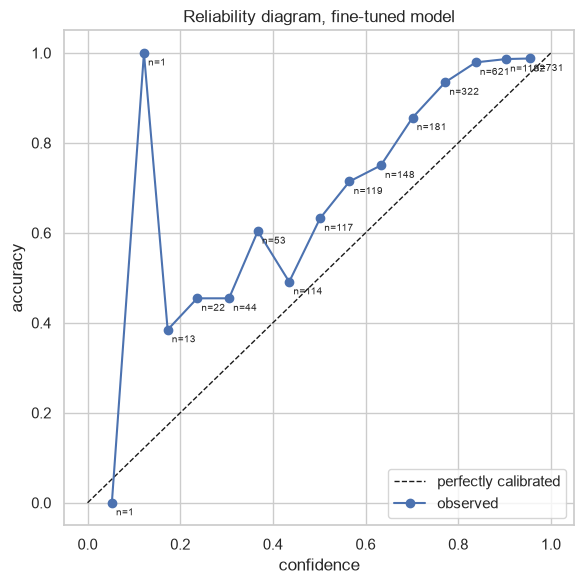

In [7]:
cal = metrics["finetuned"]["calibration"]
bins = pd.DataFrame(metrics["finetuned"]["calibration_bins"])
print(f"expected calibration error : {cal['ece']:.4f}")
print(f"mean confidence            : {cal['mean_confidence']:.4f}")
print(f"accuracy                   : {cal['accuracy']:.4f}")

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "k--", lw=1, label="perfectly calibrated")
ax.plot(bins["confidence"], bins["accuracy"], "o-", color="#4C72B0", label="observed")
for _, r in bins.iterrows():
    ax.annotate(f"n={int(r['n'])}", (r["confidence"], r["accuracy"]),
                fontsize=7, xytext=(3, -9), textcoords="offset points")
ax.set_xlabel("confidence"); ax.set_ylabel("accuracy")
ax.set_title("Reliability diagram, fine-tuned model")
ax.legend(); plt.tight_layout(); plt.show()

A point below the diagonal means the model is more confident than it is
accurate in that band. The bin counts matter as much as the positions: most
predictions land in the top band, so that bin dominates the ECE.

## 7. What the ladder actually shows

Read bottom-up, the ladder separates four different claims that a single
headline accuracy would blur together:

- Hand-designed features get **9.1%**. Fine-grained breed recognition was
  not close to solved before deep learning.
- A stock ImageNet classifier, untrained on this data, gets **98.5%** on the
  breeds ImageNet names. Most of the apparent difficulty of this benchmark
  was already paid for by someone else's labelling effort.
- The remaining question — can a model learn breeds ImageNet never named —
  is answered by the right-hand bars in section 2, and that is the only
  column where the transfer models are doing genuinely new work.